# Cluster Analysis

Qui l'obiettivo sarà quello di andare a cercare gruppi e accorpamenti significativi nei dati a disposizioni con il fine di ottenere nuove informazioni. Procederemo come di seguito il primo approccio sarà andare a raggruppare le feature per tematiche logiche sul significato semantico che queste feature e i dati da esse contenute esprimono e una volta ottenute queste divisioni tematiche andremo a effettuare le tecniche di clustering per capire se i gruppi ritrovati ci permettano di discernere l'abbandono o meno del cliente oppure ci fonriscano altre informazioni utili. Alla fine del processo effettueremo un cluster usando tutte le feature attualmente in gioco e valuteremo con alcune tecniche di visulizzazione che ci permetteranno di plottare i dati multi dimensionali in un nuovo spazio bidimensionale.

Quindi partiamo da un nuovo notebook e impostiamo uno scheletro di lavoro modulare che ti permetta:
- Caricamento e pulizia iniziale
- leggi il CSV dalla stessa cartella del notebook,
- separi le colonne Naive Bayes in un DataFrame a parte, mantieni il dataset pulito per l’analisi.

*GRUPPI LOGICI* definiamo insiemi di feature legate semanticamente:<br>
- Demografia
- Comportamento/attività
- Utilizzo carta/credito
- Transazioni

*PREPROCESSING* differenziato per tipologia feature: <br>
- numeriche → StandardScaler,
- categoriche → OneHotEncoder,
- pipeline con ColumnTransformer per ogni blocco.

*CLUSTERING*: <br>
- applichi KMeans (con scelta k basata su silhouette/elbow),
- applichi DBSCAN (con grid su eps/min_samples),
- salvi etichette cluster per ogni blocco e metodo.
- Valutazione dei cluster
- silhouette score,
- numero di cluster trovati,
- dimensioni cluster,
- churn rate medio nei cluster (per vedere se discriminano bene il target).
- (Opzionale) Visualizzazione in 2D (PCA o t-SNE) solo se utile per interpretare meglio.

### Gruppi tematici di accorpamento variabili

Identificare “sottosistemi” logici ovvero blocchi naturali che si presentano nel dataset:
- Demografia: Customer_Age, Gender, Dependent_count, Education_Level, Marital_Status, Income_Category.
- Comportamento/attività: Months_on_book, Months_Inactive_12_mon, Contacts_Count_12_mon, Total_Relationship_Count.
- Utilizzo carta / credito: Credit_Limit, Total_Revolving_Bal, Avg_Open_To_Buy, Avg_Utilization_Ratio.
- Transazioni: Total_Trans_Amt, Total_Trans_Ct, Total_Amt_Chng_Q4_Q1, Total_Ct_Chng_Q4_Q1.

In [1]:
# =======================
# STEP 1: Caricamento dati
# =======================

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Carica il dataset (CSV nella stessa cartella del notebook)
df = pd.read_csv("BankChurners.csv")

# Separa colonne Naive Bayes
nb_cols = [c for c in df.columns if "Naive" in c or "Naive_Bayes" in c]
df_naive = df[nb_cols].copy()
df_clean = df.drop(columns=nb_cols)

print("Shape dataset pulito:", df_clean.shape)
print("Shape colonne Naive:", df_naive.shape)

Shape dataset pulito: (10127, 21)
Shape colonne Naive: (10127, 2)


In [2]:
df_clean = df_clean.drop(axis=1, labels="CLIENTNUM")
df_clean

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [3]:
# =======================
# STEP 2: Definizione blocchi di feature
# =======================

blocks = {
    "Demografia": [
        "Customer_Age", "Gender", "Dependent_count",
        "Education_Level", "Marital_Status", "Income_Category"
    ],
    "Comportamento": [
        "Months_on_book", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon", "Total_Relationship_Count"
    ],
    "Utilizzo": [
        "Credit_Limit", "Total_Revolving_Bal",
        "Avg_Open_To_Buy", "Avg_Utilization_Ratio"
    ],
    "Transazioni": [
        "Total_Trans_Amt", "Total_Trans_Ct",
        "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1"
    ]
}

In [4]:
# =======================
# STEP 3: Preprocessing
# =======================

def build_preprocessor(features, df):
    """Crea un ColumnTransformer per numeriche (scaling) e categoriche (one-hot)."""
    numeric = df[features].select_dtypes(include=["int64","float64"]).columns.tolist()
    categorical = df[features].select_dtypes(exclude=["int64","float64"]).columns.tolist()
    
    transformers = []
    if numeric:
        transformers.append(("num", StandardScaler(), numeric))
    if categorical:
        transformers.append(("cat", OneHotEncoder(drop="first"), categorical))
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor, numeric, categorical

In [5]:
# =======================
# STEP 4: Clustering function
# =======================

def cluster_block(df, features, method="kmeans", k=3, eps=0.5, min_samples=5):
    """Applica clustering a un blocco di feature con preprocessing."""
    preprocessor, num_cols, cat_cols = build_preprocessor(features, df)
    
    X = df[features]
    X_proc = preprocessor.fit_transform(X)
    
    if method == "kmeans":
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_proc)
    elif method == "dbscan":
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_proc)
    else:
        raise ValueError("method deve essere 'kmeans' o 'dbscan'")
    
    return labels, X_proc, model, preprocessor # qui in caso di problemi togli il ritono di preprocesor

In [6]:
# =======================
# STEP 5: Analisi cluster (KMeans vs DBSCAN)
# =======================

def evaluate_clusters(labels, X_proc, method="kmeans"):
    """
    Valuta i cluster in base al metodo:
    - KMeans -> silhouette score
    - DBSCAN -> Davies-Bouldin, Calinski-Harabasz + stats
    """
    metrics = {}
    X_array = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc
    
    if method == "kmeans":
        if len(set(labels)) > 1:
            metrics["silhouette"] = silhouette_score(X_array, labels)
        else:
            metrics["silhouette"] = None
    
    elif method == "dbscan":
        unique_labels = set(labels)
        n_clusters = len([l for l in unique_labels if l != -1])
        n_noise = list(labels).count(-1)
        perc_noise = n_noise / len(labels)
        
        metrics["n_clusters"] = n_clusters
        metrics["perc_noise"] = perc_noise
        
        if n_clusters > 1:
            # Calcoliamo DBI e CHI solo escludendo il noise
            valid_idx = labels != -1
            metrics["davies_bouldin"] = davies_bouldin_score(X_array[valid_idx], labels[valid_idx])
            metrics["calinski_harabasz"] = calinski_harabasz_score(X_array[valid_idx], labels[valid_idx])
        else:
            metrics["davies_bouldin"] = None
            metrics["calinski_harabasz"] = None
    
    return metrics

Qui possiamo usare questa parte di codice per capire se il k applicato per il ritrovamento dei gruppi risulta buono o meno e in seguito eseguire ulteriori approfondimenti in base ai risultati trovati.

In [8]:
# =======================
# STEP 6: Applicazione ai blocchi
# =======================

results = {}

for block_name, features in blocks.items():
    print(f"\n--- Clustering su blocco: {block_name} ---")
    
    # KMeans (esempio con k=3)
    labels_kmeans, Xk, model_k, pre_pro_k = cluster_block(df_clean, features, method="kmeans", k=3)
    metrics_k = evaluate_clusters(labels_kmeans, Xk, method="kmeans")
    print("KMeans metrics:", metrics_k)
    
    # DBSCAN (parametri iniziali eps/min_samples da calibrare)
    labels_dbscan, Xd, model_d, pre_pro_d = cluster_block(df_clean, features, method="dbscan", eps=1.5, min_samples=10)
    metrics_db = evaluate_clusters(labels_dbscan, Xd, method="dbscan")
    print("DBSCAN metrics:", metrics_db)
    
    # Salvo risultati
    results[block_name] = {
        "kmeans_labels": labels_kmeans,
        "dbscan_labels": labels_dbscan,
        "metrics_kmeans": metrics_k,
        "metrics_dbscan": metrics_db
    }
    
    # Aggiungo le etichette al dataframe
    df_clean[f"{block_name}_kmeans"] = labels_kmeans
    df_clean[f"{block_name}_dbscan"] = labels_dbscan


--- Clustering su blocco: Demografia ---
KMeans metrics: {'silhouette': 0.16999205247529797}
DBSCAN metrics: {'n_clusters': 1, 'perc_noise': 0.0, 'davies_bouldin': None, 'calinski_harabasz': None}

--- Clustering su blocco: Comportamento ---
KMeans metrics: {'silhouette': 0.175294800480318}
DBSCAN metrics: {'n_clusters': 1, 'perc_noise': 0.0002962377801915671, 'davies_bouldin': None, 'calinski_harabasz': None}

--- Clustering su blocco: Utilizzo ---
KMeans metrics: {'silhouette': 0.46315664987658695}
DBSCAN metrics: {'n_clusters': 1, 'perc_noise': 0.0, 'davies_bouldin': None, 'calinski_harabasz': None}

--- Clustering su blocco: Transazioni ---
KMeans metrics: {'silhouette': 0.3119150616223782}
DBSCAN metrics: {'n_clusters': 1, 'perc_noise': 0.0014811889009578355, 'davies_bouldin': None, 'calinski_harabasz': None}


In [9]:
# =======================
# STEP 7: Esplorazione dei cluster trovati
# =======================

# Esempio: distribuzione churn (Attrition_Flag) nei cluster demografia (KMeans)
if "Attrition_Flag" in df_clean.columns:
    churn_by_cluster = df_clean.groupby("Demografia_kmeans")["Attrition_Flag"].value_counts(normalize=True).unstack()
    print("\nDistribuzione churn nei cluster (Demografia, KMeans):")
    print(churn_by_cluster)


Distribuzione churn nei cluster (Demografia, KMeans):
Attrition_Flag     Attrited Customer  Existing Customer
Demografia_kmeans                                      
0                           0.170914           0.829086
1                           0.159460           0.840540
2                           0.145230           0.854770


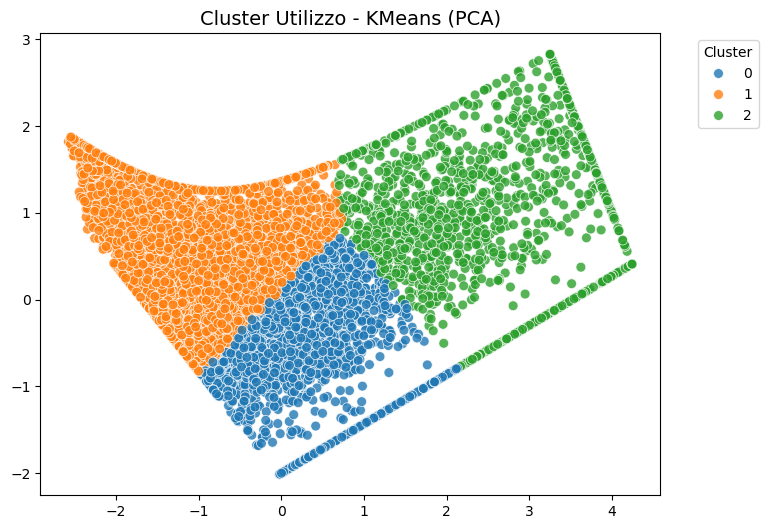

/opt/anaconda3/envs/FPDScourse/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


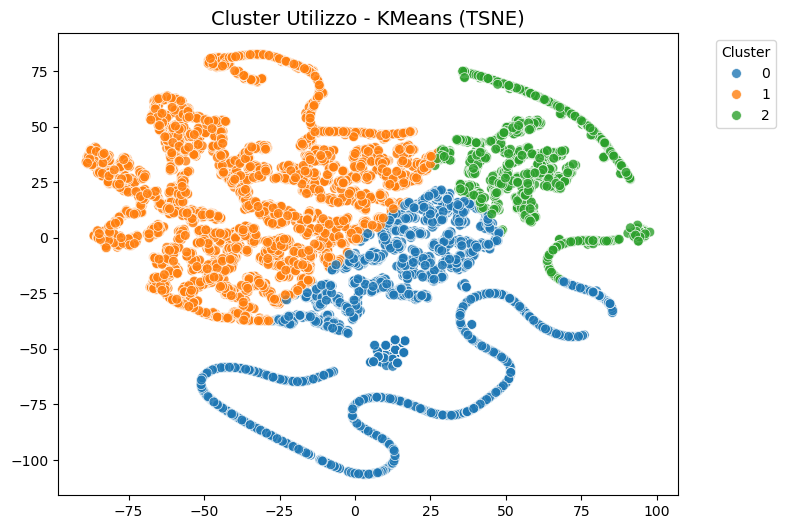

In [10]:
"""
⚠️ Nota:
PCA è molto veloce, utile per una prima ispezione.
t-SNE è più pesante ma può rivelare strutture non lineari, meglio per visualizzazione qualitativa.


Come funziona
La funzione visualize_clusters riduce i dati preprocessati (X_proc) a 2 dimensioni.
Puoi scegliere method="pca" o method="tsne".
I punti sono colorati in base alle etichette dei cluster.
"""

# =======================
# STEP 8: Visualizzazione 2D opzionale (PCA / t-SNE)
# =======================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_clusters(X_proc, labels, method="pca", title="Cluster Visualization"):
    """
    Visualizza i cluster in 2D usando PCA o t-SNE.
    """
    if method == "pca":
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        X_2d = reducer.fit_transform(X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc)
    else:
        raise ValueError("method deve essere 'pca' o 'tsne'")
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=X_2d[:,0], y=X_2d[:,1], hue=labels,
        palette="tab10", s=50, alpha=0.8
    )
    plt.title(f"{title} ({method.upper()})", fontsize=14)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


# =======================
# Esempio di utilizzo
# =======================

# Visualizza cluster per blocco "Utilizzo" con KMeans
labels = results["Utilizzo"]["kmeans_labels"]
X_proc = cluster_block(df_clean, blocks["Utilizzo"], method="kmeans", k=3)[1]

visualize_clusters(X_proc, labels, method="pca", title="Cluster Utilizzo - KMeans")
visualize_clusters(X_proc, labels, method="tsne", title="Cluster Utilizzo - KMeans")


In [11]:
# =======================
# STEP 8: Visualizzazione 2D opzionale
# =======================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_clusters(X_proc, labels, method="pca", title="Cluster Visualization"):
    """
    Visualizza i cluster in 2D usando PCA o t-SNE.
    """
    X_array = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc
    
    if method == "pca":
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X_array)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        X_2d = reducer.fit_transform(X_array)
    else:
        raise ValueError("method deve essere 'pca' o 'tsne'")
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=X_2d[:,0], y=X_2d[:,1], hue=labels,
        palette="tab10", s=50, alpha=0.8
    )
    plt.title(f"{title} ({method.upper()})", fontsize=14)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


Distribuzione churn nei cluster (Demografia, KMeans):
Attrition_Flag     Attrited Customer  Existing Customer
Demografia_kmeans                                      
0                           0.170914           0.829086
1                           0.159460           0.840540
2                           0.145230           0.854770


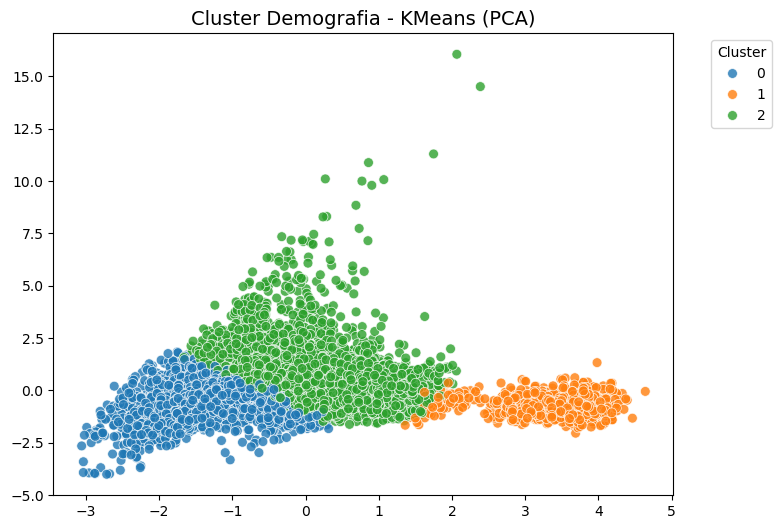

/opt/anaconda3/envs/FPDScourse/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


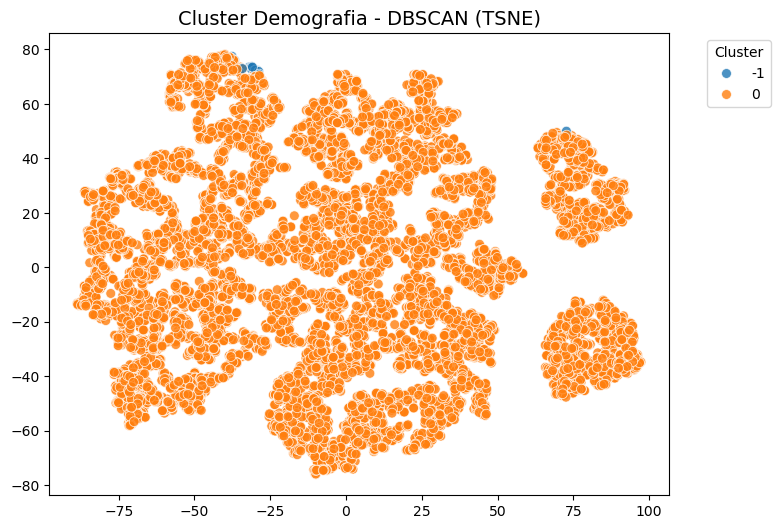

In [12]:
# Esempio: distribuzione churn (Attrition_Flag) nei cluster demografia (KMeans)
if "Attrition_Flag" in df_clean.columns:
    churn_by_cluster = df_clean.groupby("Demografia_kmeans")["Attrition_Flag"].value_counts(normalize=True).unstack()
    print("\nDistribuzione churn nei cluster (Demografia, KMeans):")
    print(churn_by_cluster)

# =======================
# Esempio di visualizzazione 2D (puoi richiamarlo su qualsiasi blocco in seguito)
# =======================

visualize_clusters(Xk, labels_kmeans, method="pca", title="Cluster Demografia - KMeans")
visualize_clusters(Xd, labels_dbscan, method="tsne", title="Cluster Demografia - DBSCAN")


## funzioni per andare a estrarre valore dai cluster eseguiti


In [13]:
# IMPORTS necessari
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, kruskal, chi2_contingency, ttest_ind
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, adjusted_rand_score
import math

# -------------------------
# 1) Profiling dei cluster
# -------------------------
def profile_clusters(df, features, labels, top_n_numeric=5, top_n_cat=3):
    """
    Ritorna:
      - dataframe con medie/std per numeriche per cluster
      - dict con top features distintive (z-score) per cluster
      - tabelle di conteggio per categoriche
    """
    res = {}
    feat_df = df[features].copy()
    feat_df['__cluster__'] = labels
    clusters = sorted(list(set(labels)))
    numeric = feat_df.select_dtypes(include=[np.number]).columns.tolist()
    if '__cluster__' in numeric: numeric.remove('__cluster__')
    categorical = [c for c in features if c not in numeric]

    # Global stats
    global_mean = feat_df[numeric].mean()
    global_std = feat_df[numeric].std(ddof=0).replace(0, np.nan)

    # Numeric profiles
    profile_num = feat_df.groupby('__cluster__')[numeric].agg(['mean','std','count'])
    profile_num.columns = ['_'.join(col).strip() for col in profile_num.columns.values]
    
    # z-scores per cluster: (mean_cluster - mean_global) / std_global
    z = {}
    for c in clusters:
        row = profile_num.loc[c]
        mean_cols = {f: row[f"{f}_mean"] for f in numeric}
        zc = {}
        for f in numeric:
            if not np.isnan(global_std[f]):
                zc[f] = (mean_cols[f] - global_mean[f]) / global_std[f]
            else:
                zc[f] = np.nan
        # pick top absolute z
        top = sorted(zc.items(), key=lambda x: -abs(x[1]))[:top_n_numeric]
        z[c] = top

    # Categorical profiles
    cat_profiles = {}
    for cat in categorical:
        ct = feat_df.groupby('__cluster__')[cat].value_counts(normalize=True).unstack(fill_value=0)
        overall = feat_df[cat].value_counts(normalize=True)
        cat_profiles[cat] = (ct, overall)
    
    return {
        "profile_num": profile_num,
        "zscore_highlights": z,
        "cat_profiles": cat_profiles
    }

# -------------------------
# 2) test statistici e effect size
# -------------------------
def cluster_stats_tests(df, features, labels):
    """
    Per ogni numeric: ANOVA or Kruskal (se non-normal) tra i gruppi.
    Per ogni categorical: chi2 tra cluster assignment e categoria.
    Ritorna risultati sintetici.
    """
    import warnings
    warnings.filterwarnings("ignore")
    res = {"numeric":{}, "categorical":{}}
    feat_df = df[features].copy()
    feat_df['__cluster__'] = labels
    numeric = feat_df.select_dtypes(include=[np.number]).columns.tolist()
    if '__cluster__' in numeric: numeric.remove('__cluster__')
    categorical = [c for c in features if c not in numeric]

    # numeric tests (ANOVA and pairwise Cohen's d vs rest)
    for f in numeric:
        groups = [group[f].dropna().values for name, group in feat_df.groupby('__cluster__')]
        if len(groups) > 1:
            try:
                p = f_oneway(*groups).pvalue
            except Exception:
                p = kruskal(*groups).pvalue
        else:
            p = np.nan
        # compute Cohen's d between each cluster and rest
        cohens = {}
        for c in set(labels):
            a = feat_df[feat_df['__cluster__']==c][f].dropna()
            b = feat_df[feat_df['__cluster__']!=c][f].dropna()
            if len(a)>1 and len(b)>1:
                # pooled std
                sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
                d = (a.mean() - b.mean()) / sd if sd>0 else np.nan
            else:
                d = np.nan
            cohens[c] = d
        res["numeric"][f] = {"p_global": p, "cohen_d_by_cluster": cohens}

    # categorical tests (chi2)
    for c in categorical:
        ct = pd.crosstab(feat_df['__cluster__'], feat_df[c])
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, exp = chi2_contingency(ct)
        else:
            p = np.nan
        res["categorical"][c] = {"p_chi2": p}
    return res

# -------------------------
# 3) estrazione regole via albero (spiegabilità)
# -------------------------
def extract_rules_from_preprocessed(X_proc, preprocessor, labels, max_depth=4):
    """
    Allena un DecisionTree su X_proc -> labels e stampa regole umane.
    preprocessor: ColumnTransformer usato per X_proc (serve per ricostruire feature names)
    """
    # ricostruisci nomi feature da preprocessor
    feature_names = []
    # num
    if 'num' in preprocessor.named_transformers_:
        num_cols = preprocessor.named_transformers_['num'].feature_names_in_.tolist()
        feature_names.extend(num_cols)
    else:
        num_cols = []
    # cat
    if 'cat' in preprocessor.named_transformers_:
        enc = preprocessor.named_transformers_['cat']
        cat_cols = enc.feature_names_in_.tolist()
        cat_ohe_names = enc.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(cat_ohe_names)
    # X_proc -> array
    Xa = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
    clf.fit(Xa, labels)
    rules_text = export_text(clf, feature_names=feature_names)
    return rules_text, clf

# -------------------------
# 4) nominare cluster automaticamente (bozza)
# -------------------------
def name_clusters_automatically(profile_num_df, zscore_highlights, cat_profiles, numeric_prefix=""):
    """
    Crea etichette sintetiche: prende i top z-score e le categorie con maggior enrichment.
    Ritorna dict cluster_id -> suggested_name
    """
    names = {}
    for c, toplist in zscore_highlights.items():
        parts = []
        # toplist = list of (feature, z)
        for f, z in toplist[:3]:
            if np.isnan(z): continue
            if abs(z) < 0.35:
                continue
            side = "High" if z>0 else "Low"
            # short name: togli underscore e parole lunghe
            fname_short = f.replace("_","")
            parts.append(f"{side}_{fname_short}")
        # categorical enrichment: prendi up to 2
        for cat, (ct, overall) in cat_profiles.items():
            if c not in ct.index: 
                continue
            row = ct.loc[c]
            # get most enriched categories (ratio vs overall > 1.3)
            enrich = (row / overall).sort_values(ascending=False)
            top = enrich[enrich>1.3].index.tolist()[:1]
            if top:
                parts.append(f"{cat}_{top[0]}")
        if not parts:
            name = f"cluster_{c}"
        else:
            name = "__".join(parts[:3])
        names[c] = name
    return names

# -------------------------
# 5) aggiungi feature cluster al dataset e valutazione di utilità su churn
# -------------------------
def add_cluster_features_and_test(df, cluster_col, target_col="Attrition_Flag"):
    """Aggiunge one-hot dei cluster e testa se migliorano un semplice modello di churn."""
    d = df.copy()
    # one-hot
    oh = pd.get_dummies(d[cluster_col].astype(str), prefix=cluster_col)
    X = pd.get_dummies(d.drop(columns=[target_col]), drop_first=True)  # naive baseline features
    # NOTE: a questo punto scegli le colonne che vuoi usare realmente come baseline
    # Per demo: useremo solo numeric originali: (meglio definire esplicitamente)
    # Qui semplifico: confrontiamo modello con vs senza cluster OH
    X_base = X.select_dtypes(include=[np.number]).fillna(0)
    X_with = pd.concat([X_base, oh], axis=1).fillna(0)
    y = (d[target_col] == "Attrited Customer").astype(int) if d[target_col].dtype==object else d[target_col]
    # modello semplice
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    clf = LogisticRegression(max_iter=1000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    auc_base = cross_val_score(clf, X_base, y, cv=cv, scoring="roc_auc").mean()
    auc_with = cross_val_score(clf, X_with, y, cv=cv, scoring="roc_auc").mean()
    return {"auc_base": auc_base, "auc_with_cluster": auc_with}


In [15]:
block = "Utilizzo"
features = blocks[block]

# 1) prendi i risultati KMeans / DBSCAN eseguiti prima
labels_k = results[block]["kmeans_labels"]
labels_db = results[block]["dbscan_labels"]

In [17]:
# 3) test statistici
tests_k = cluster_stats_tests(df_clean, features, labels_k)
print(tests_k["numeric"]["Credit_Limit"]["cohen_d_by_cluster"])

{0: -0.4124608312802489, 1: -1.0567725772207268, 2: 4.862796295798796}


In [16]:
# 2) profila KMeans
prof_k = profile_clusters(df_clean, features, labels_k)
print(prof_k["profile_num"].head())
print("Top z:", prof_k["zscore_highlights"])

             Credit_Limit_mean  Credit_Limit_std  Credit_Limit_count  \
__cluster__                                                            
0                  6288.736990       4343.756872                3674   
1                  4132.870151       2744.836155                4764   
2                 26419.172291       6897.179890                1689   

             Total_Revolving_Bal_mean  Total_Revolving_Bal_std  \
__cluster__                                                      
0                          405.441753               530.480149   
1                         1709.340260               487.928743   
2                         1268.755477               773.063715   

             Total_Revolving_Bal_count  Avg_Open_To_Buy_mean  \
__cluster__                                                    
0                                 3674           5883.295237   
1                                 4764           2423.529891   
2                                 1689          2515

In [21]:
# 4) estrai regole (serve preprocessor e X_proc dall'esecuzione di cluster_block)
# Prepara preprocessor e dati
preprocessor, _, _ = build_preprocessor(features, df_clean)
X = df_clean[features]
X_proc = preprocessor.fit_transform(X)   # <-- qui il preprocessor viene fittato

# Ora il preprocessor ha l’attributo .transformers_
labels, X_proc, model, _ = cluster_block(df_clean, features, method="kmeans", k=3)

# Passa il preprocessor già fittato
rules, tree_model = extract_rules_from_preprocessed(X_proc, preprocessor, labels, max_depth=3)
print(rules)


|--- Avg_Utilization_Ratio <= -0.38
|   |--- Credit_Limit <= 0.75
|   |   |--- Total_Revolving_Bal <= 0.66
|   |   |   |--- class: 0
|   |   |--- Total_Revolving_Bal >  0.66
|   |   |   |--- class: 1
|   |--- Credit_Limit >  0.75
|   |   |--- Credit_Limit <= 1.05
|   |   |   |--- class: 2
|   |   |--- Credit_Limit >  1.05
|   |   |   |--- class: 2
|--- Avg_Utilization_Ratio >  -0.38
|   |--- Avg_Utilization_Ratio <= 0.02
|   |   |--- Total_Revolving_Bal <= 0.11
|   |   |   |--- class: 0
|   |   |--- Total_Revolving_Bal >  0.11
|   |   |   |--- class: 1
|   |--- Avg_Utilization_Ratio >  0.02
|   |   |--- Total_Revolving_Bal <= -0.61
|   |   |   |--- class: 0
|   |   |--- Total_Revolving_Bal >  -0.61
|   |   |   |--- class: 1



In [29]:
# ESEGUI IN SEGUITO PER ORA NON E' IMPORTATNTE

# 5) auto-naming
# names_map = name_clusters_automatically(prof_k["profile_num"], prof_k["zscore_highlights"], prof_k["cat_profiles"])
#print(names_map)
#df_clean[f"{block}_kmeans_name"] = df_clean[f"{block}_kmeans"].map(names_map)

# 6) verifica utilità sui churn
#test_res = add_cluster_features_and_test(df_clean, f"{block}_kmeans", target_col="Attrition_Flag")
#print(test_res)

## Analisi di ogni blocco di feature 

🔑 Cosa fa questo codice
- Selezioni un blocco cambiando solo block_name = "Demografia" (puoi metterci "Comportamento", "Utilizzo", "Transazioni").
- Esegue solo KMeans, con k che puoi modificare.

Ti dà:
- le metriche (silhouette ecc.),
- la distribuzione dei cluster,
- la relazione con Attrition_Flag (se ti interessa),
- la visualizzazione in 2D con PCA e t-SNE,
- regole interpretative (se vuoi).

In [142]:
# =======================
# Analisi su un singolo blocco (es. "Demografia")
# =======================

# 1) scegli il blocco da analizzare
block_name = "Utilizzo" #  Demografia poco significativo, Comportamento k=2 o 5, Utilizzo k=3, Transazioni k=2
features = blocks[block_name]

print(f"\n--- Analisi dettagliata blocco: {block_name} ---")
print(f"Variabili prese in considerazione per il cluster:\n {features}"), 


--- Analisi dettagliata blocco: Utilizzo ---
Variabili prese in considerazione per il cluster:
 ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio']


(None,)

In [145]:
# 2) Applica KMeans (qui con k=3, ma puoi cambiare k e rifare analisi)
labels_kmeans, X_proc, model_k, preproc_data = cluster_block(df_clean, features, method="kmeans", k=3)

In [146]:
# 3) Valutazione del clustering
metrics_k = evaluate_clusters(labels_kmeans, X_proc, method="kmeans")
print("KMeans metrics:", metrics_k)

# 4) Aggiungi le etichette al dataframe per analisi successive
#df_clean[f"{block_name}_kmeans"] = labels_kmeans

KMeans metrics: {'silhouette': 0.46315664987658695}


In [147]:
# 5) Analisi di base: distribuzione dei cluster
print("\nDistribuzione cluster:")
print(pd.Series(labels_kmeans).value_counts())


Distribuzione cluster:
1    4764
0    3674
2    1689
Name: count, dtype: int64


In [148]:
# 6) (Opzionale) Relazione con Attrition_Flag
if "Attrition_Flag" in df_clean.columns:
    churn_by_cluster = df_clean.groupby(f"{block_name}_kmeans")["Attrition_Flag"].value_counts(normalize=True).unstack()
    print("\nDistribuzione Attrition_Flag nei cluster:")
    print(churn_by_cluster)


Distribuzione Attrition_Flag nei cluster:
Attrition_Flag   Attrited Customer  Existing Customer
Utilizzo_kmeans                                      
0                         0.272727           0.727273
1                         0.085642           0.914358
2                         0.128478           0.871522


In [149]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_clusters_2d(X_proc, labels, method="pca", title="Cluster Visualization"):
    """
    Riduce i dati a 2D con PCA o t-SNE e visualizza i cluster.
    
    Args:
        X_proc: ndarray o sparse matrix (dati preprocessati)
        labels: array con etichette di cluster
        method: "pca" o "tsne"
        title: titolo del grafico
    """
    if method == "pca":
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate="auto", init="random")
        X_2d = reducer.fit_transform(X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc)
    else:
        raise ValueError("method deve essere 'pca' o 'tsne'")
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels, palette="tab10", s=50, alpha=0.7)
    plt.title(title)
    plt.legend(title="Cluster")
    plt.show()


### uso pca e t-sne visualizzazione dati da migliorare

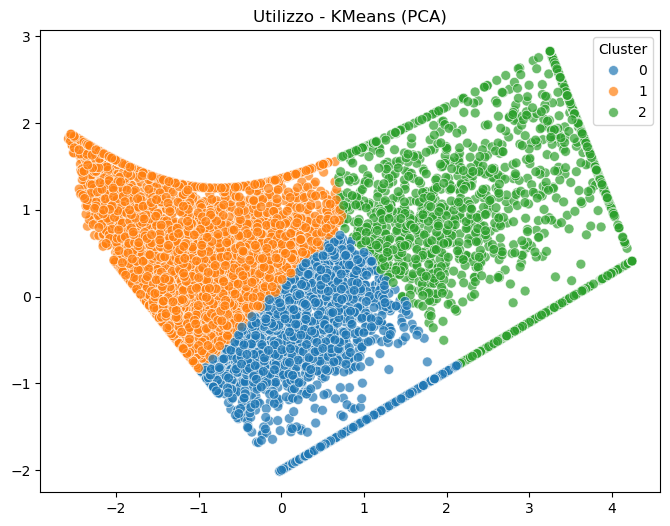

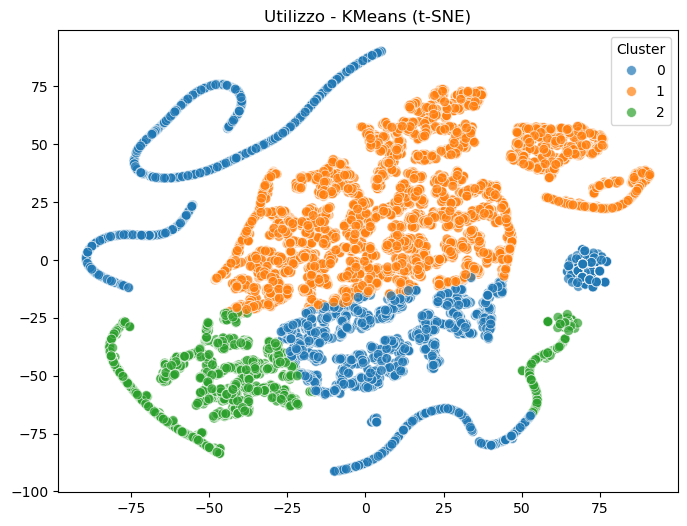

In [150]:
# BISOGNA CAPIRE SUGLI ASSI CHE MISURE STA USANDO 
# 7) Visualizzazione 2D (puoi scegliere 'pca' o 'tsne')
plot_clusters_2d(X_proc, labels_kmeans, method="pca", title=f"{block_name} - KMeans (PCA)")
plot_clusters_2d(X_proc, labels_kmeans, method="tsne", title=f"{block_name} - KMeans (t-SNE)")

### da controllare

In [151]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, _tree

# --- ricava i nomi delle feature dal ColumnTransformer fittato ---
def get_feature_names(column_transformer):
    feature_names = []
    for name, transformer, cols in column_transformer.transformers_:
        if transformer == 'drop' or transformer is None:
            continue
        try:
            cols_list = list(cols)
        except Exception:
            cols_list = [cols]
        if hasattr(transformer, "get_feature_names_out"):
            try:
                names = transformer.get_feature_names_out(cols_list)
            except Exception:
                names = transformer.get_feature_names_out()
            feature_names.extend([str(n) for n in names])
        else:
            feature_names.extend([str(c) for c in cols_list])
    return feature_names


# --- costruisce dizionario per invertire le trasformazioni ---
def get_inverse_transform_info(preprocessor):
    """
    Restituisce un dizionario feature_name -> info per inversione.
    Gestisce solo StandardScaler e OneHotEncoder(drop='first').
    """
    inv_info = {}
    for name, transformer, cols in preprocessor.transformers_:
        if transformer == 'drop' or transformer is None:
            continue
        if hasattr(transformer, 'get_feature_names_out'):
            transformed_names = transformer.get_feature_names_out(cols)
        else:
            transformed_names = cols

        if name == 'num':  # StandardScaler
            for i, f in enumerate(transformed_names):
                inv_info[f] = {
                    'type': 'standard',
                    'mean': float(transformer.mean_[i]),
                    'scale': float(transformer.scale_[i]),
                    'orig_name': cols[i]
                }

        elif name == 'cat':  # OneHotEncoder(drop='first')
            start_idx = 0
            for col_i, col in enumerate(cols):
                cats = transformer.categories_[col_i][1:]  # drop='first'
                for cat in cats:
                    f = transformed_names[start_idx]
                    inv_info[f] = {
                        'type': 'onehot',
                        'col_name': col,
                        'category': cat
                    }
                    start_idx += 1
    return inv_info


# --- converte una singola condizione in termini originali ---
def condition_to_original(cond, inv_info):
    # cond è tipo "feature <= valore"
    try:
        fname, op, val = cond.split()
        val = float(val)
    except Exception:
        return cond  # se il formato non è riconosciuto, lascio invariato

    info = inv_info.get(fname, None)
    if info is None:
        return cond
    if info['type'] == 'standard':
        orig_val = val * info['scale'] + info['mean']
        return f"{info['orig_name']} {op} {round(orig_val, 6)}"
    elif info['type'] == 'onehot':
        if op == '<=':
            return f"{info['col_name']} != {info['category']}"
        else:  # op == '>'
            return f"{info['col_name']} == {info['category']}"
    else:
        return cond


# --- estrae regole con soglie riportate alle feature originali ---
def tree_to_rules_with_counts(clf, feature_names, preprocessor=None, X=None, y=None):
    tree = clf.tree_
    feature = tree.feature
    threshold = tree.threshold
    children_left = tree.children_left
    children_right = tree.children_right
    value = tree.value

    rules = []

    # mappatura leaf -> esempi
    if X is not None and y is not None:
        X_arr = X.toarray() if hasattr(X, "toarray") else X
        y_arr = np.asarray(y)
        leaf_ids_all = clf.apply(X_arr)
        classes = list(clf.classes_)
    else:
        leaf_ids_all = None
        classes = list(clf.classes_) if hasattr(clf, "classes_") else []

    # costruisci info per inversione se preprocessor fornito
    if preprocessor is not None:
        inv_info = get_inverse_transform_info(preprocessor)
    else:
        inv_info = {}

    def recurse(node, conditions):
        if feature[node] != _tree.TREE_UNDEFINED:
            fname = feature_names[feature[node]]
            thr = threshold[node]
            # left <= thr
            recurse(children_left[node], conditions + [f"{fname} <= {round(float(thr), 6)}"])
            # right > thr
            recurse(children_right[node], conditions + [f"{fname} > {round(float(thr), 6)}"])
        else:
            # foglia
            if leaf_ids_all is not None and y is not None:
                idx = np.where(leaf_ids_all == node)[0]
                samples = int(len(idx))
                counts = [int(np.sum(y_arr[idx] == cls)) for cls in classes]
                pred_index = int(np.argmax(counts)) if samples > 0 else int(np.argmax(value[node][0]))
                pred_cluster = classes[pred_index] if len(classes) > 0 else pred_index
            else:
                val = value[node][0]
                counts = [int(x) for x in np.round(val).astype(int).tolist()]
                samples = int(sum(counts))
                pred_index = int(np.argmax(val)) if len(val) > 0 else 0
                pred_cluster = classes[pred_index] if len(classes) > 0 else pred_index

            # applica inversione sulle condizioni
            conditions_orig = [condition_to_original(c, inv_info) for c in conditions]

            rules.append({
                "conditions": conditions_orig,
                "pred_index": pred_index,
                "pred_cluster": pred_cluster,
                "samples": samples,
                "counts": counts
            })

    recurse(0, [])
    return rules


# --- stampa regole in formato leggibile ---
def print_rules_custom(rules):
    for i, r in enumerate(rules, 1):
        cond_str = " AND ".join(r["conditions"]) if len(r["conditions"]) > 0 else "TRUE"
        print(f"\nRule {i}")
        print(f"{cond_str} THEN cluster {r['pred_cluster']}")
        print(f"Rule {i} — samples: {r['samples']} — distribuzione cluster: {r['counts']}")


In [153]:
# Assumendo tree_model fittato e preproc fittato
feature_names = get_feature_names(preproc_data)
Xa = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc

rules = tree_to_rules_with_counts(tree_model, feature_names, preprocessor=preproc_data, X=Xa, y=labels_kmeans)
print_rules_custom(rules)



Rule 1
Avg_Utilization_Ratio <= 0.1695 AND Credit_Limit <= 15469.502663 AND Total_Revolving_Bal <= 1702.499737 THEN cluster 0
Rule 1 — samples: 3079 — distribuzione cluster: [3057, 9, 13]

Rule 2
Avg_Utilization_Ratio <= 0.1695 AND Credit_Limit <= 15469.502663 AND Total_Revolving_Bal > 1702.499737 THEN cluster 1
Rule 2 — samples: 132 — distribuzione cluster: [10, 99, 23]

Rule 3
Avg_Utilization_Ratio <= 0.1695 AND Credit_Limit > 15469.502663 AND Credit_Limit <= 18190.002736 THEN cluster 2
Rule 3 — samples: 320 — distribuzione cluster: [104, 1, 215]

Rule 4
Avg_Utilization_Ratio <= 0.1695 AND Credit_Limit > 15469.502663 AND Credit_Limit > 18190.002736 THEN cluster 2
Rule 4 — samples: 1438 — distribuzione cluster: [0, 0, 1438]

Rule 5
Avg_Utilization_Ratio > 0.1695 AND Avg_Utilization_Ratio <= 0.2815 AND Total_Revolving_Bal <= 1256.000002 THEN cluster 0
Rule 5 — samples: 394 — distribuzione cluster: [362, 32, 0]

Rule 6
Avg_Utilization_Ratio > 0.1695 AND Avg_Utilization_Ratio <= 0.2815 

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import copy

def plot_tree_original_thresholds(tree_model, preprocessor, feature_names, class_names=None, figsize=(14,8), fontsize=10):
    """
    Plotta l'albero con le soglie convertite nel dominio originale.
    - tree_model: modello DecisionTreeClassifier già addestrato su dati preprocessati
    - preprocessor: ColumnTransformer usato per preprocessare X
    - feature_names: lista di feature preprocessate (feature_names_out)
    - class_names: lista di nomi delle classi
    """

    # 1. ottieni info per inversione
    inv_info = get_inverse_transform_info(preprocessor)

    # 2. crea copia dell'albero per non modificare l'originale
    tree_copy = copy.deepcopy(tree_model)

    # 3. inverti le soglie
    for i, f_idx in enumerate(tree_copy.tree_.feature):
        if f_idx != -2:  # TREE_UNDEFINED
            fname = feature_names[f_idx]
            info = inv_info.get(fname, None)
            if info is not None and info['type'] == 'standard':
                tree_copy.tree_.threshold[i] = tree_copy.tree_.threshold[i] * info['scale'] + info['mean']
            # per OneHotEncoder non serve modificare la soglia perché è sempre 0.5

    # 4. rinomina feature per plot
    feature_names_orig = []
    for f in feature_names:
        info = inv_info.get(f, None)
        if info is None:
            feature_names_orig.append(f)
        elif info['type'] == 'standard':
            feature_names_orig.append(info['orig_name'])
        elif info['type'] == 'onehot':
            feature_names_orig.append(f"{info['col_name']}=={info['category']}")
        else:
            feature_names_orig.append(f)

    # 5. plot
    plt.figure(figsize=figsize)
    plot_tree(tree_copy, 
              feature_names=feature_names_orig, 
              class_names=[str(c) for c in class_names] if class_names is not None else None,
              filled=True, rounded=True, fontsize=fontsize)
    plt.show()


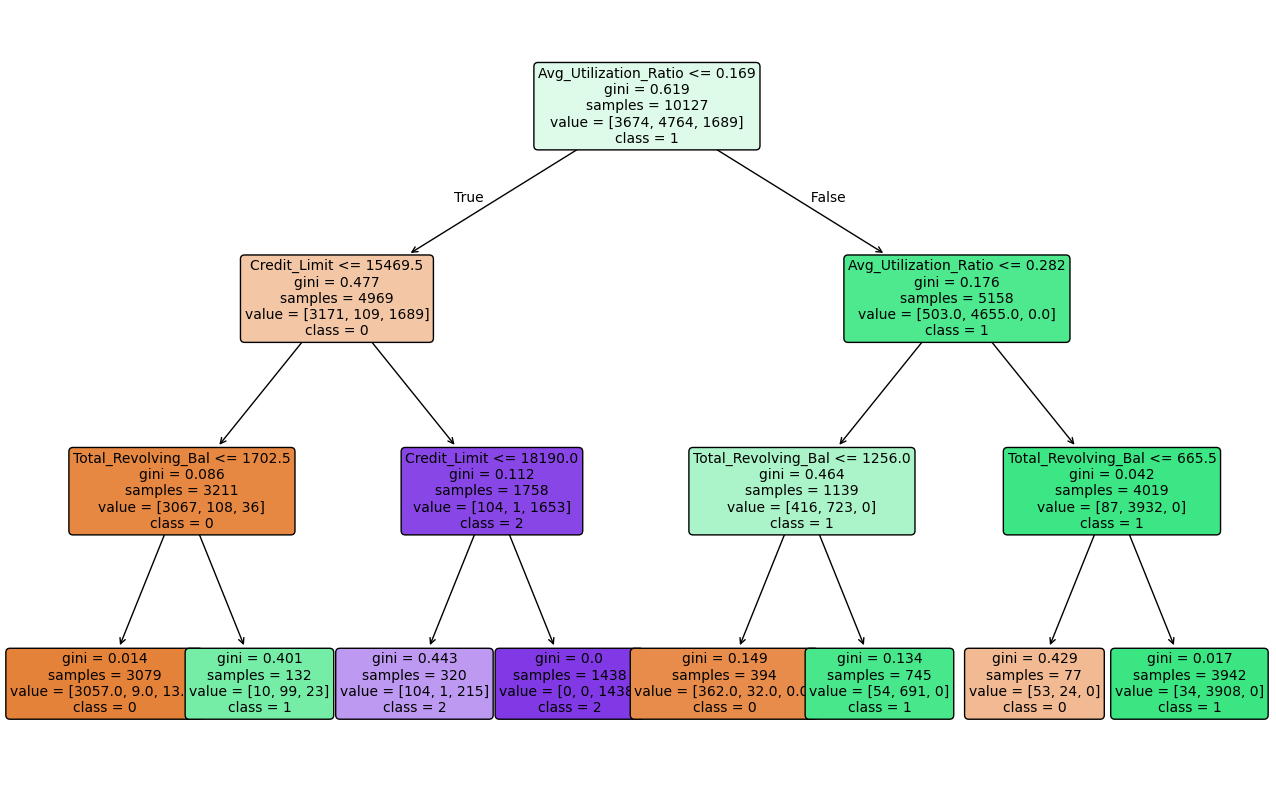

In [155]:
feature_names = get_feature_names(preproc)
plot_tree_original_thresholds(
    tree_model=tree_model,
    preprocessor=preproc,
    feature_names=feature_names,
    class_names=list(set(labels_kmeans)),
    figsize=(16,10),
    fontsize=10
)


# cluster usando tutte le feature in gioco